In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Instagram_with_captions.csv to Instagram_with_captions.csv


In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer=SentimentIntensityAnalyzer()
df=pd.read_csv("Instagram_with_captions.csv")
text=df["caption"].iloc[0]
analyzer.polarity_scores(text)

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [ ]:
df["sentiment_score"]=df["caption"].apply(
    lambda x : analyzer.polarity_scores(str(x))["compound"]

)
def get_sentiment(scores) :
  if scores >= 0.05:
    return "positive"
  elif scores<=-0.:
    return "negative"
  else:
    return "neutral"



In [ ]:
df["sentiments"].value_counts()

,count
sentiments,
positive,22940
negative,7059


In [ ]:
df["sentiments"].value_counts(normalize=True)*100

,proportion
sentiments,
positive,76.469216
negative,23.530784


In [ ]:
import pandas as pd
df=pd.read_csv("Instagram_with_captions.csv")
print(df.isnull().sum())

post_id                     0
caption                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
dtype: int64


In [ ]:
from nltk.metrics import scores
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer=SentimentIntensityAnalyzer()

df["sentiment_score"]=df["caption"].apply(

lambda x : analyzer.polarity_scores(str(x))["compound"]
)
def get_sentiment(scores) :
 if scores>=0.05 :
    return "positive"
 elif scores<=0.05 :
    return "negative"
 else :
    return "neutral"
df["sentiments"]=df["sentiment_score"].apply(get_sentiment)
df[["caption","sentiment_score","sentiments"]].head(10)


,caption,sentiment_score,sentiments
0,"New technology, new possibilities. What do you...",0.0000,negative
1,"Training today, getting stronger tomorrow. Kee...",0.4389,positive
2,Sharing this moment with the community. Hope y...,0.8478,positive
3,A new sound for your playlist. Turn it up and ...,0.4939,positive
4,Innovation is moving fast. Here is one technol...,0.5423,positive
5,"Exploring light, perspective and the beauty of...",0.5859,positive
6,Food brings people together. Here is today's f...,0.4588,positive
7,Innovation is moving fast. Here is one technol...,0.5423,positive
8,A quick update from today's content. Let us kn...,0.0000,negative
9,A new sound for your playlist. Turn it up and ...,0.4939,positive


In [ ]:
df["sentiments"].value_counts()

,count
sentiments,
positive,22940
negative,7059


In [ ]:
df["sentiments"].value_counts(normalize=True)*100

,proportion
sentiments,
positive,76.469216
negative,23.530784


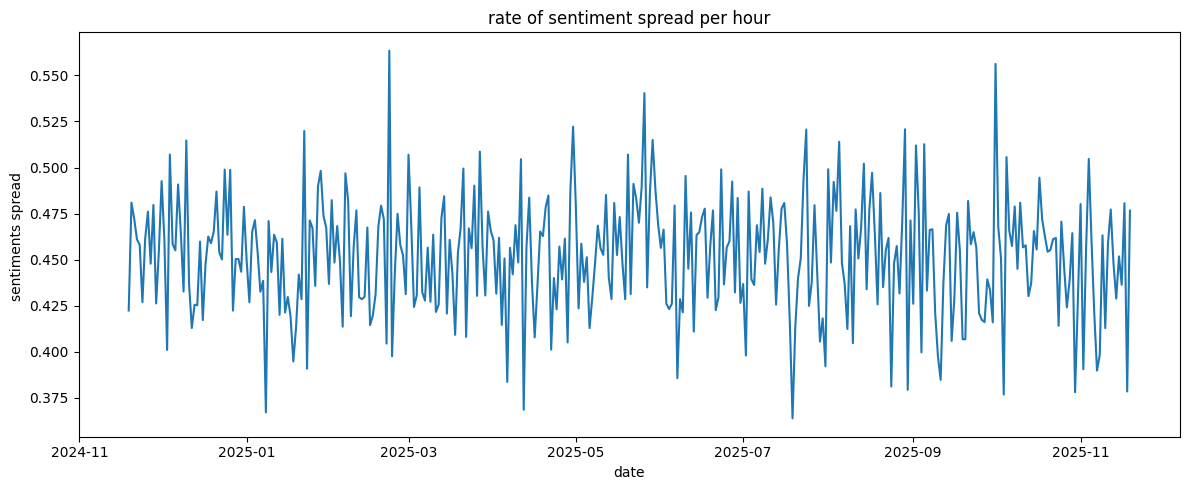

In [ ]:
import matplotlib.pyplot as plt
df["post_date"]=pd.to_datetime(df["post_date"])
sentimens_over_time=df.groupby("post_date")["sentiment_score"].mean()
plt.figure(figsize=(12,5))
plt.plot(
    sentimens_over_time.index,
    sentimens_over_time.values

)
plt.xlabel("date")
plt.ylabel("sentiments spread ")
plt.title("rate of sentiment spread per hour")
plt.tight_layout()
plt.show()

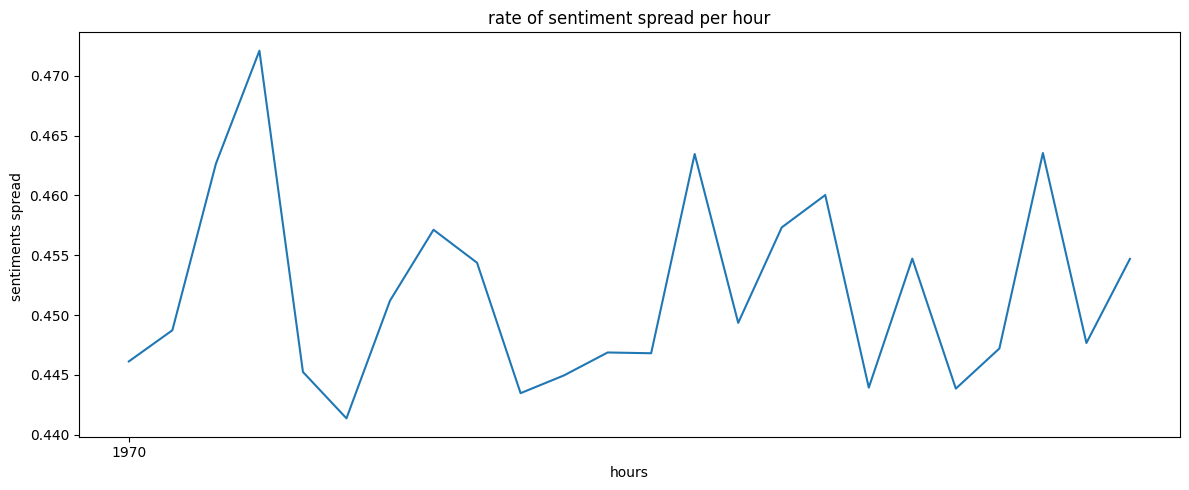

In [ ]:
import matplotlib.pyplot as plt
df["post_hour"]=pd.to_datetime(df["post_hour"])
sentimens_over_time=df.groupby("post_hour")["sentiment_score"].mean()
sentiment_spread_over_time = sentiment_spread_over_time.reindex(
    columns=["positive", "negative", "neutral"],
    fill_value=0
)

plt.figure(figsize=(12,5))
plt.plot(
    sentimens_over_time.index,
    sentimens_over_time.values

)
plt.xlabel("hours")
plt.ylabel("sentiments spread ")
plt.title("rate of sentiment spread per hour")
plt.tight_layout()
plt.show()

KeyError: 'neutral'

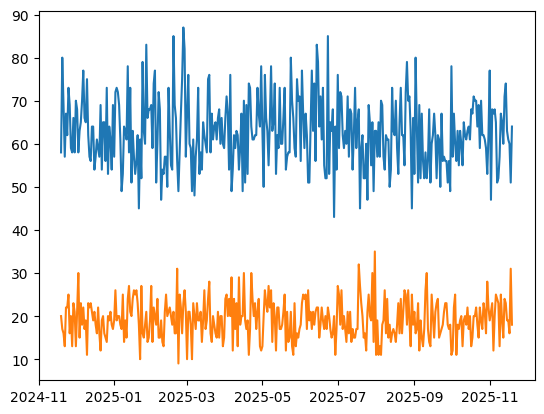

In [ ]:
sentiment_spread_over_time=df.groupby(
   ["post_date","sentiments"]

).size().unstack(fill_value=0)

plt.plot(
    sentiment_spread_over_time.index,
    sentiment_spread_over_time["positive"],
    label="positive"

)
plt.plot(
    sentiment_spread_over_time.index,
    sentiment_spread_over_time["negative"],
    label="negative"

)
plt.plot(
    sentiment_spread_over_time.index,
    sentiment_spread_over_time["neutral"],
    label="neutral"

)
plt.xlabel("dates")
plt.ylabel("sentiments")
plt.title("sentiment spread over date")
plt.legend()
plt.tight_layout()
plt.show()